In [144]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [145]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data;
        self.grad = 0.0
        self._backward = lambda:None
        self._prev=set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out=Value(self.data +other.data,(self,other),'+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out

    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out=Value(self.data *other.data,(self,other),'*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    def __pow__(self,other):
        assert isinstance(other,(int,float)),"only supporting int/float powers for now"
        out =Value(self.data**other,(self,),f'**{other}')
        
        def _backward():
            self.grad += other *self.data**(other-1)* out.grad
        out._backward = _backward
        
        return out

    def __radd__(self, other): # other + self
        return self + other
        
    def __rmul__(self,other):#other * self
        return self*other

    def __truediv__(self,other):#self/other
        return self* other**-1

    def __neg__(self):
        return self*-1

    def __sub__(self,other):
        return self +(-other)
        
    def tanh(self):
        x = self.data
        th = (math.exp(x*2)-1)/(math.exp(x*2)+1)
        out = Value(th,(self,),'tanh')

        def _backward():
            self.grad += (1.0 - th**2)*out.grad
        out._backward = _backward
        
        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out


    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self,),'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out

                    

    def backward(self):
        topo = []
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [146]:
a = Value(2.0,label='a')
b=Value(4.0)
a-b
0+a

Value(data=2.0)

In [147]:
from graphviz import Digraph

def trace(root):
    #bulid a set of all nodes and edges in a graph
    nodes,edges=set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot=Digraph(format='svg',graph_attr={'rankdir':'LR'})# LR = left to right

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        #for any value in the graph,create a rectangular('record') node for it
        dot.node(name=uid,label="{%s | data %.4f | grad %.4f}"%(n.label,n.data,n.grad),shape='record')
        if n._op:
            #if this value is a result of some operation,create an op node for it
            dot.node(name = uid+ n._op,label=n._op)
            #and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1,n2 in edges:
        #connect n1 to the op node of n2
        dot.edge(str(id(n1)),str(id(n2))+n2._op)

    return dot
        

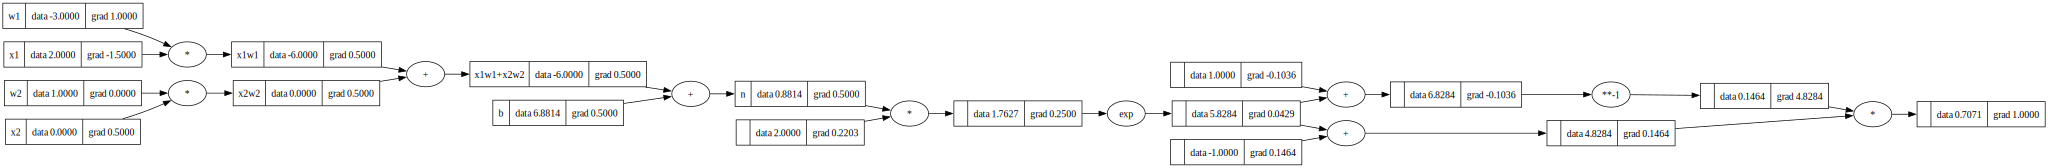

In [148]:
#inouts x1 x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
#weights
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label = 'w2')

b= Value(6.881373,label = 'b')

x1w1 = x1*w1;x1w1.label='x1w1'
x2w2 = x2*w2;x2w2.label='x2w2'

x1w1x2w2 = x1w1+x2w2;x1w1x2w2.label='x1w1+x2w2'
n = x1w1x2w2 + b ;n.label ='n'
#o = n.tanh();o.lable='o'
e = (2*n).exp()
o = (e-1)/(e+1)
o.lable='o'



o.backward()
draw_dot(o)

In [153]:
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        

    def __call__(self,x):
            # w * x + b
        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w+[self.b]


class Layer:
    def __init__(self,nin,nout):#nin表示当前层接受的输入个数，nout表示每层有几个神经元
        self.neurons= [Neuron(nin) for _ in range(nout)]
    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self,nin,nouts):
        sz = [nin]+nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
        
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

        
x=[2.0,3.0,-1.0]


n = MLP(3,[4,4,1])
n(x)
#draw_dot(n(x))

Value(data=0.5787030042891792)

In [154]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
]

ys =[1.0,-1.0,-1.0,1.0]


In [155]:
for k in range(20):
    # forward pass
    ypred=[n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt,yout in zip(ys,ypred))

    #backward pass
    loss.backward()

    #update
    for p in n.parameters():
        p.data += 0.05 * p.grad

    print(k,loss.data)


0 6.640079045525958
1 7.55054766322614
2 7.926163933173765
3 7.98582997606288
4 7.994814226939704
5 7.9979070095879425
6 7.999209459115286
7 7.999706343229994
8 7.999889953643829
9 7.999958242329445
10 7.99998398593067
11 7.999993807213822
12 7.999997589248716
13 7.99999905643065
14 7.999999629010352
15 7.999999853573741
16 7.99999994201567
17 7.999999976972494
18 7.999999990832076
19 7.999999996341935


In [156]:
ypred

[Value(data=0.9999999991342071),
 Value(data=0.9999999995341945),
 Value(data=0.9999999995512894),
 Value(data=0.9999999988409423)]